In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler

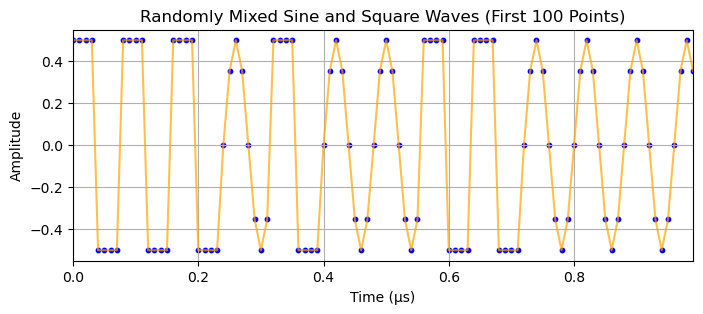

In [32]:
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mixed_waves',n=8, total_points = 1000, window_size=4, plot=True)

In [33]:
train_size = 750  # Training set size
window_size = 4
# Split into training and testing sets
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [34]:
X_test[0]

array([-0.5, -0.5,  0.5,  0.5])

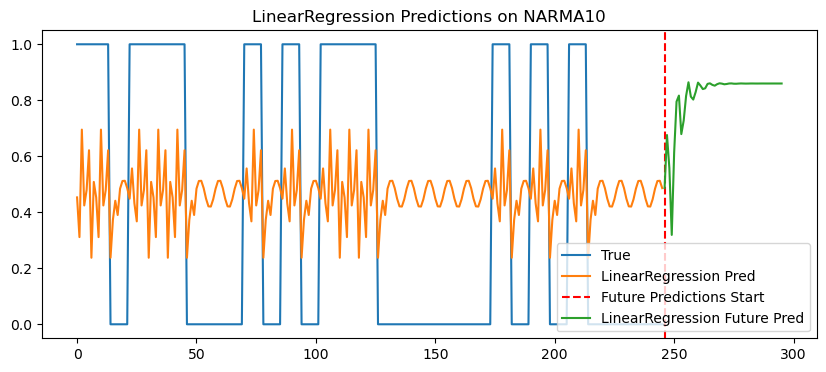

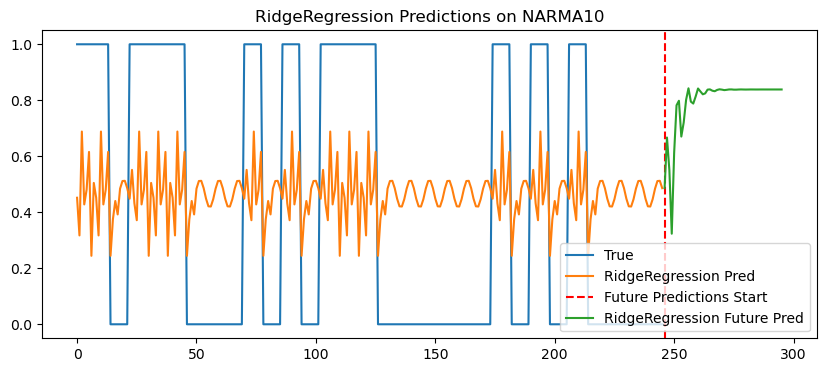

Model RMSE Scores:
LinearRegression: 0.4856
RidgeRegression: 0.4857


In [35]:
models = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0)
}

results = {}
n_predictions = 50  # Number of future values to predict

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    results[name] = rmse
    
    # Predict next n values iteratively
    future_predictions = list(X_test[-1])
    for _ in range(n_predictions):
        next_input = np.array(future_predictions[-window_size:]).reshape(1, -1)
        next_pred = model.predict(next_input)[0]
        future_predictions.append(next_pred)
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_test, label="True")
    plt.plot(predictions, label=f"{name} Pred")
    plt.axvline(len(y_test), color='r', linestyle='--', label="Future Predictions Start")
    plt.plot(range(len(y_test), len(y_test) + n_predictions), future_predictions[-n_predictions:], label=f"{name} Future Pred")
    plt.title(f"{name} Predictions on NARMA10")
    plt.legend()
    plt.show()

# Compare results
print("Model RMSE Scores:")
for model, rmse in results.items():
    print(f"{model}: {rmse:.4f}")


In [36]:
from ESN import EchoStateNetwork
from reservoirs import CPRC, GBPermanents

In [37]:
dim=len(X_train[0])
cprc = CPRC(dim=dim, execution_mode='simulation')
esn = EchoStateNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.8, 
    show_progress=True, 
    approach='time-multiplexing', # 'feedback', or 'time-multiplexing'
    model_type='ridge'  # Options: 'ridge', 'lasso', 'linear', 'svr'
)

In [38]:
esn.fit(X_train, y_train)

Training Progress: 100%|████████████████| 750/750 [00:04<00:00, 174.28 sample/s]


In [39]:
predictions = esn.predict(X_test)
print(predictions)

Prediction Progress: 100%|██████████████| 246/246 [00:01<00:00, 185.60 sample/s]

[ 0.96824419  0.74184301  0.53426744  0.53426744  0.94107283  1.08627723
  0.28002784  0.28002784  0.96824419  0.74184301  0.53426744  0.53426744
  0.94107283  1.08627723  0.28002784  0.28002784  0.69415284  0.01366004
  0.33543225  0.59385434  0.25032052 -0.00989628  0.29502375  0.5403321
  0.50267005  0.72696457  0.53426744  0.53426744  0.94107283  1.08627723
  0.28002784  0.28002784  0.96824419  0.74184301  0.53426744  0.53426744
  0.94107283  1.08627723  0.28002784  0.28002784  0.96824419  0.74184301
  0.53426744  0.53426744  0.94107283  1.08627723  0.28002784  0.28002784
  0.69415284  0.01366004  0.33543225  0.59385434  0.25032052 -0.00989628
  0.29502375  0.5403321   0.31805952  0.06864137  0.33543225  0.59385434
  0.25032052 -0.00989628  0.29502375  0.5403321   0.31805952  0.06864137
  0.33543225  0.59385434  0.25032052 -0.00989628  0.29502375  0.5403321
  0.50267005  0.72696457  0.53426744  0.53426744  0.94107283  1.08627723
  0.28002784  0.28002784  0.69415284  0.01366004  0.3

In [40]:
n = 10 
m = 5 
initial_input = X_train[-1]  

future_predictions = esn.predict_next_n_trained(X_test=X_test, initial_input=initial_input, n=n, m=m)
print(future_predictions)

Sequential Prediction Progress: 100%|███████| 10/10 [00:00<00:00, 129.45 step/s]

[0.28002784 0.96824419 0.93090508 0.13048871 2.41618204 0.96824419
 0.74184301 0.64409655 2.56318155 1.49864495]


Quantum ESN RMSE: 0.3933


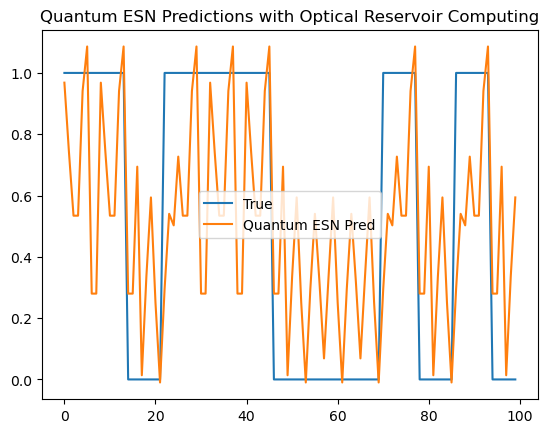

In [41]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")
# Plot Predictions
plt.plot(y_test[0:100], label="True")
plt.plot(predictions[0:100], label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [42]:
dim=len(X_train[0])
gbp = GBPermanents(network_connections=[[3, 2], [2, 1], [3, 2], [2, 1]], classical=True, kernel=False)
esn = EchoStateNetwork(
    reservoir=gbp, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.8, 
    show_progress=True, 
    approach='time-multiplexing', # 'feedback', or 'time-multiplexing'
    model_type='ridge'  # Options: 'ridge', 'lasso', 'linear', 'svr'
)

In [43]:
esn.fit(X_train, y_train)

Training Progress: 100%|███████████████| 750/750 [00:00<00:00, 1356.69 sample/s]


In [44]:
predictions = esn.predict(X_test)
# print(predictions)

Prediction Progress: 100%|█████████████| 246/246 [00:00<00:00, 1417.07 sample/s]


Quantum ESN RMSE: 0.3443


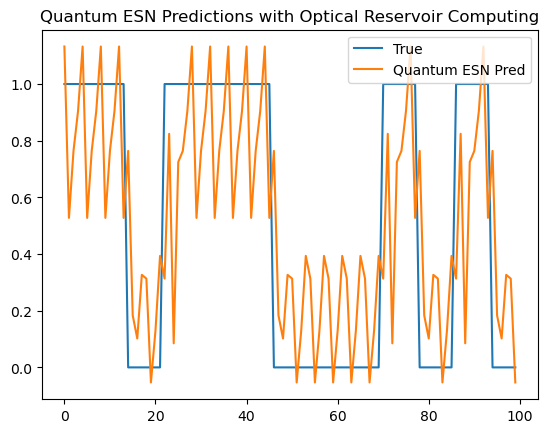

In [45]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Quantum ESN RMSE: {rmse:.4f}")
# Plot Predictions
plt.plot(y_test[0:100], label="True")
plt.plot(predictions[0:100], label="Quantum ESN Pred")
plt.title("Quantum ESN Predictions with Optical Reservoir Computing")
plt.legend()
plt.show()

In [46]:
import os

BASE_DIR = "QRC"

# Define datasets and reservoirs
datasets = ["MG", "Mixed_Waves", "NARMA10"]  # You can update with actual dataset names
reservoirs = ["GBSampling", "GBPermanent_Classical", "CPMap"]
num_runs = 5  # Number of runs for each experiment

def create_experiment_folders():
    """Creates the directory structure for experiments automatically."""
    os.makedirs(BASE_DIR, exist_ok=True)  # Ensure base directory exists
    
    for dataset in datasets:
        dataset_path = os.path.join(BASE_DIR, dataset)
        os.makedirs(dataset_path, exist_ok=True)  # Create dataset folder
        
        for reservoir in reservoirs:
            reservoir_path = os.path.join(dataset_path, reservoir)
            os.makedirs(reservoir_path, exist_ok=True)  # Create reservoir folder
            
            for run_id in range(1, num_runs + 1):
                run_path = os.path.join(reservoir_path, f"Run_{run_id}")
                os.makedirs(run_path, exist_ok=True)  # Create run folder
    
    print("✅ Folder structure created successfully!")

# Run the function to create the structure
create_experiment_folders()


✅ Folder structure created successfully!
